In [56]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("abhi8923shriv/sentiment-analysis-dataset")

# print("Path to dataset files:", path)

[Link ke dataset](https://www.kaggle.com/datasets/abhi8923shriv/sentiment-analysis-dataset/code)

In [57]:
import pandas as pd

In [58]:

path = r'sentiment_data\train.csv'
data_train = pd.read_csv(path, encoding='latin-1')

data_train.head()

,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26


In [59]:

path_2 = r'sentiment_data\test.csv'
data_test = pd.read_csv(path_2, encoding='latin-1')

data_test.head()

,textID,text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,f87dea47db,Last session of the day http://twitpic.com/67ezh,neutral,morning,0-20,Afghanistan,38928346.0,652860.0,60.0
1,96d74cb729,Shanghai is also really exciting (precisely -...,positive,noon,21-30,Albania,2877797.0,27400.0,105.0
2,eee518ae67,"Recession hit Veronique Branquinho, she has to...",negative,night,31-45,Algeria,43851044.0,2381740.0,18.0
3,01082688c6,happy bday!,positive,morning,46-60,Andorra,77265.0,470.0,164.0
4,33987a8ee5,http://twitpic.com/4w75p - I like it!!,positive,noon,60-70,Angola,32866272.0,1246700.0,26.0


In [60]:
# Ambil kolom text dan sentiment saja
train_df = data_train[['text', 'sentiment']]
test_df = data_test[['text', 'sentiment']]

# Pastikan tidak ada nilai kosong (NaN) agar tidak error saat preprocessing
train_df = train_df.dropna()
test_df = test_df.dropna()


In [61]:
import re
import nltk
from nltk.corpus import stopwords

# Download list stopword bahasa inggris
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # 1. Ubah ke lowercase
    text = text.lower()
    
    # 2. Hapus URL (http/https)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    # 3. Hapus Mention (@user) dan Hashtag (#)
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)
    text = re.sub(r'#', '', text)
    
    # 4. Hapus tanda baca dan angka
    text = re.sub(r'[^a-z\s]', '', text)
    
    # 5. Hapus Stopwords
    text = ' '.join([word for word in text.split() if word not in stop_words])
    
    return text


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [62]:
# Terapkan pembersihan
train_df['text_clean'] = train_df['text'].apply(clean_text)
test_df['text_clean'] = test_df['text'].apply(clean_text)

# Lihat perbandingannya
print(train_df[['text', 'text_clean']].head())


                                                text  \
0                I`d have responded, if I were going   
1      Sooo SAD I will miss you here in San Diego!!!   
2                          my boss is bullying me...   
3                     what interview! leave me alone   
4   Sons of ****, why couldn`t they put them on t...   

                                 text_clean  
0                        id responded going  
1                   sooo sad miss san diego  
2                             boss bullying  
3                     interview leave alone  
4  sons couldnt put releases already bought  


In [63]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
import pickle

# 1. Encode Sentiment (Label ke Angka)
le = LabelEncoder()
train_labels = le.fit_transform(train_df['sentiment'])
test_labels = le.transform(test_df['sentiment'])

# 2. Convert ke One-Hot (karena ada 3 kelas)
train_labels = tf.keras.utils.to_categorical(train_labels)
test_labels = tf.keras.utils.to_categorical(test_labels)

# 3. Tokenisasi Teks
vocab_size = 10000
max_length = 100
trunc_type = 'post'
padding_type = 'post'
oov_tok = "<OOV>"

tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(train_df['text_clean'])

# Ubah teks menjadi sequence angka
train_sequences = tokenizer.texts_to_sequences(train_df['text_clean'])
train_padded = pad_sequences(train_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

test_sequences = tokenizer.texts_to_sequences(test_df['text_clean'])
test_padded = pad_sequences(test_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)



# Menyimpan tokenizer ke dalam file .pickle
with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)
    
print("File tokenizer.pickle berhasil disimpan!")

File tokenizer.pickle berhasil disimpan!


In [64]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size, 64, input_length=max_length),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
    tf.keras.layers.GlobalMaxPool1D(),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    # Output 3 neuron untuk 3 kelas (neutral, positive, negative)
    tf.keras.layers.Dense(3, activation='softmax') 
])

model.compile(
    loss='categorical_crossentropy', 
    optimizer='adam', 
    metrics=['accuracy']
)

model.summary()


c:\ALAN\Alan\Kelas Machine Learning\venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_2          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [65]:
history = model.fit(
    train_padded, 
    train_labels, 
    epochs=10, 
    validation_data=(test_padded, test_labels),
    verbose=1
)


Epoch 1/10
859/859 ━━━━━━━━━━━━━━━━━━━━ 55s 59ms/step - accuracy: 0.6251 - loss: 0.8275 - val_accuracy: 0.7216 - val_loss: 0.6593
Epoch 2/10
859/859 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step - accuracy: 0.7539 - loss: 0.6311 - val_accuracy: 0.7252 - val_loss: 0.6619
Epoch 3/10
859/859 ━━━━━━━━━━━━━━━━━━━━ 45s 53ms/step - accuracy: 0.7983 - loss: 0.5385 - val_accuracy: 0.7199 - val_loss: 0.6817
Epoch 4/10
859/859 ━━━━━━━━━━━━━━━━━━━━ 48s 56ms/step - accuracy: 0.8317 - loss: 0.4557 - val_accuracy: 0.7054 - val_loss: 0.7273
Epoch 5/10
859/859 ━━━━━━━━━━━━━━━━━━━━ 46s 54ms/step - accuracy: 0.8578 - loss: 0.3863 - val_accuracy: 0.6950 - val_loss: 0.8892
Epoch 6/10
859/859 ━━━━━━━━━━━━━━━━━━━━ 45s 53ms/step - accuracy: 0.8857 - loss: 0.3200 - val_accuracy: 0.6952 - val_loss: 1.0133
Epoch 7/10
859/859 ━━━━━━━━━━━━━━━━━━━━ 45s 53ms/step - accuracy: 0.9036 - loss: 0.2698 - val_accuracy: 0.6836 - val_loss: 1.2148
Epoch 8/10
859/859 ━━━━━━━━━━━━━━━━━━━━ 46s 53ms/step - accuracy: 0.9161 - loss: 0.2289 - 

In [66]:
model.save("Sentiment_model.h5")

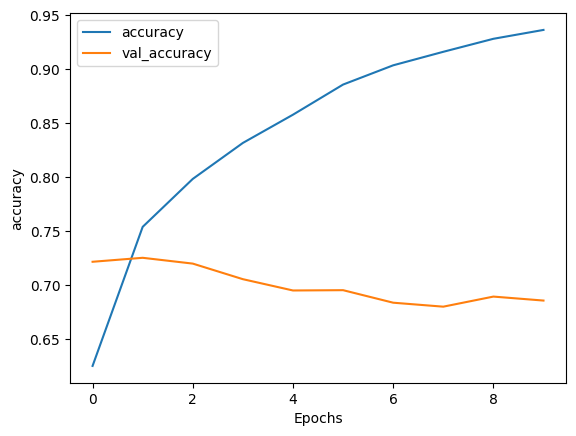

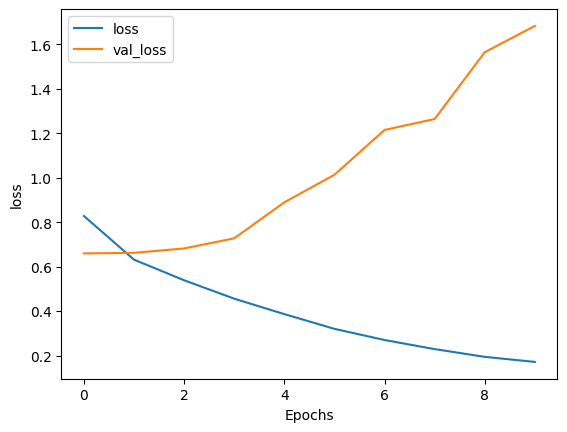

In [67]:
import matplotlib.pyplot as plt

# Buat fungsi untuk plotting
def plot_graphs(history, string):
    plt.plot(history.history[string])
    plt.plot(history.history['val_'+string])
    plt.xlabel("Epochs")
    plt.ylabel(string)
    plt.legend([string, 'val_'+string])
    plt.show()

# Tampilkan plot Akurasi
plot_graphs(history, "accuracy")

# Tampilkan plot Loss
plot_graphs(history, "loss")
